# 02: Data Cleaning

## Goal
Decide what to forecast and prepare a clean weekly series for modeling, saved to `data/processed/`.

## The decision this notebook starts with
Notebook 01 found three periods where the raw ICU counts are misleading: a change in how ICU beds were counted in fall 2020, optional reporting from May to October 2024, and late reporting in the final week. Planners act on bed counts, but forecasting the raw count would teach a model about drops in demand that never happened.

An alternative is to forecast the **share of ICU beds in use** (occupied beds divided by available beds) and convert that forecast back into beds afterward. When hospitals drop out of the totals, both their patients and their beds disappear, so the share should stay roughly the same. Notebook 01 showed this held in fall 2020 and in the final week. It has not been checked for 2024.

**Question:** Did the share of ICU beds in use stay steady during the 2024 voluntary reporting period, when the raw count fell by about half?

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

raw_data_folder = Path("../data/raw")
raw_file_path = sorted(raw_data_folder.glob("nhsn_hrd_california_weekly_*.csv"))[-1]
print("Using raw file:", raw_file_path.name)

california_weekly_raw = pd.read_csv(raw_file_path)

icu_weekly = california_weekly_raw[
    ["weekendingdate", "numicubeds", "numicubedsocc", "numicubedsoccperchosprep"]
].rename(
    columns={
        "numicubeds": "icu_beds_available",
        "numicubedsocc": "icu_beds_occupied",
        "numicubedsoccperchosprep": "pct_hospitals_reporting",
    }
)
icu_weekly["week_ending"] = pd.to_datetime(icu_weekly["weekendingdate"]).dt.normalize()
icu_weekly = icu_weekly.drop(columns="weekendingdate")
icu_weekly["icu_occupancy_share_pct"] = (
    icu_weekly["icu_beds_occupied"] / icu_weekly["icu_beds_available"] * 100
)

print(icu_weekly.shape)

Using raw file: nhsn_hrd_california_weekly_2026-10-06.csv
(321, 5)


                           weeks  avg_pct_hospitals_reporting  avg_icu_beds_occupied  avg_icu_occupancy_share_pct  min_icu_occupancy_share_pct  max_icu_occupancy_share_pct
period                                                                                                                                                                     
1. Before (required)          26                         95.4                 6820.4                         68.7                         66.4                         71.5
2. During (voluntary)         26                         51.4                 3692.7                         64.9                         59.5                         67.3
3. After (required again)     26                         92.6                 6987.7                         69.9                         64.1                         73.4


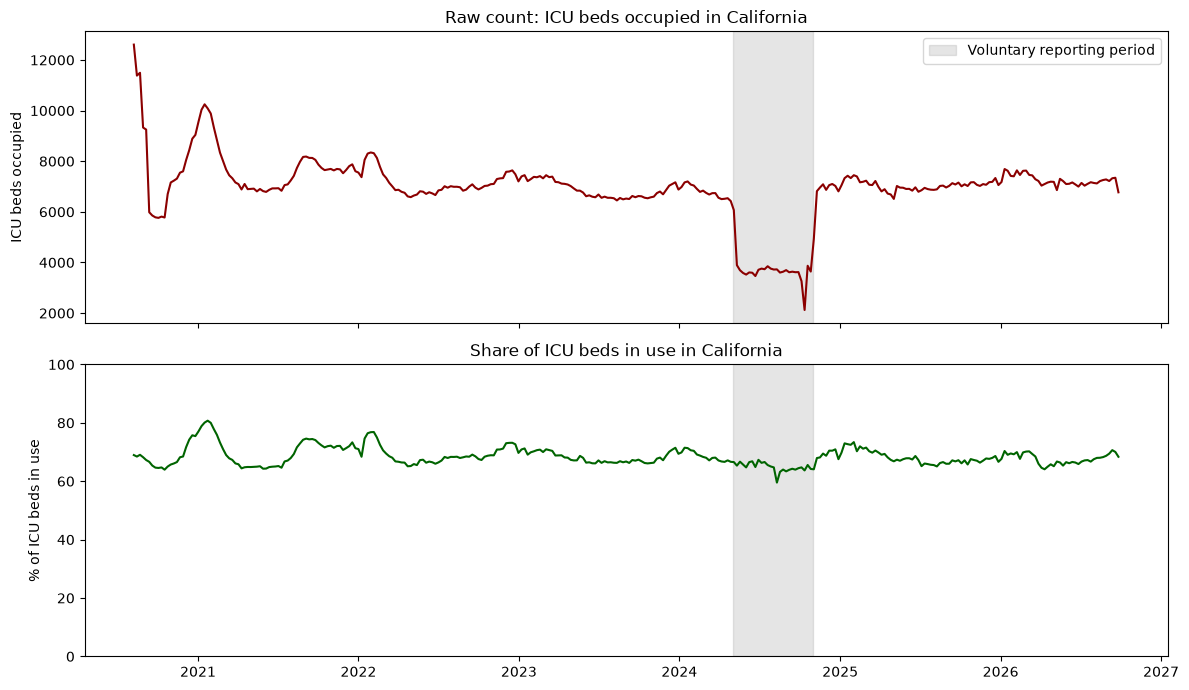

In [2]:
voluntary_period_start = pd.Timestamp("2024-05-01")
voluntary_period_end = pd.Timestamp("2024-10-31")

def label_period(week_ending):
    if week_ending < voluntary_period_start:
        return "1. Before (required)"
    if week_ending <= voluntary_period_end:
        return "2. During (voluntary)"
    return "3. After (required again)"

# Compare the 6 months on each side of the voluntary window, so all three
# periods are similar in length and season
comparison_window = icu_weekly[
    (icu_weekly["week_ending"] >= voluntary_period_start - pd.DateOffset(months=6))
    & (icu_weekly["week_ending"] <= voluntary_period_end + pd.DateOffset(months=6))
].copy()
comparison_window["period"] = comparison_window["week_ending"].apply(label_period)

period_summary = comparison_window.groupby("period").agg(
    weeks=("week_ending", "count"),
    avg_pct_hospitals_reporting=("pct_hospitals_reporting", "mean"),
    avg_icu_beds_occupied=("icu_beds_occupied", "mean"),
    avg_icu_occupancy_share_pct=("icu_occupancy_share_pct", "mean"),
    min_icu_occupancy_share_pct=("icu_occupancy_share_pct", "min"),
    max_icu_occupancy_share_pct=("icu_occupancy_share_pct", "max"),
).round(1)
print(period_summary.to_string())

figure, (count_axis, share_axis) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

count_axis.plot(icu_weekly["week_ending"], icu_weekly["icu_beds_occupied"], color="darkred")
count_axis.set_ylabel("ICU beds occupied")
count_axis.set_title("Raw count: ICU beds occupied in California")

share_axis.plot(icu_weekly["week_ending"], icu_weekly["icu_occupancy_share_pct"], color="darkgreen")
share_axis.set_ylabel("% of ICU beds in use")
share_axis.set_title("Share of ICU beds in use in California")
share_axis.set_ylim(0, 100)

for axis in (count_axis, share_axis):
    axis.axvspan(
        voluntary_period_start,
        voluntary_period_end,
        color="gray",
        alpha=0.2,
        label="Voluntary reporting period",
    )

count_axis.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Is the 2024 dip in the share caused by reporting, or by the season?

The share of ICU beds in use averaged 64.9% during the voluntary period, about 3.8 points below the 6 months before. But the voluntary period covers May to October, while the 6 months before cover mostly winter and spring, when respiratory illness fills more ICU beds. The comparison above mixes two effects: fewer hospitals reporting, and a quieter time of year.

**Method:** compare the same weeks of the year (May through October) across 2022 to 2025. Reporting was required in every year except 2024. If 2024 sits close to the other years, the dip is seasonal and the 2024 share can be used as reported. If 2024 sits clearly below them, the hospitals still reporting in 2024 were not representative, and those weeks need adjusting.

May through October of each year:
      weeks  avg_pct_hospitals_reporting  avg_icu_occupancy_share_pct  min_icu_occupancy_share_pct  max_icu_occupancy_share_pct
year                                                                                                                           
2022     26                         95.7                         67.6                         65.5                         69.1
2023     26                         95.9                         66.7                         66.1                         68.7
2024     26                         51.4                         64.9                         59.5                         67.3
2025     26                         93.8                         66.7                         65.1                         68.6


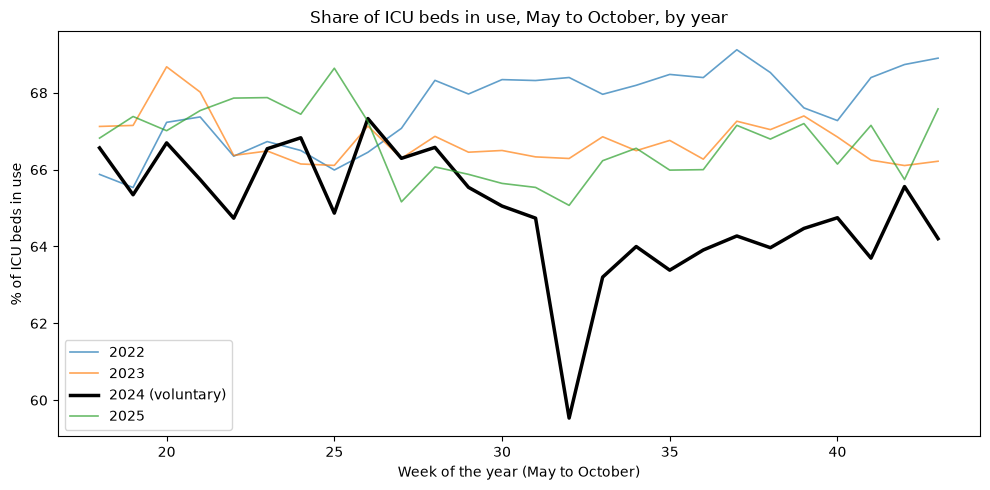

In [3]:
same_season_weeks = icu_weekly[icu_weekly["week_ending"].dt.month.between(5, 10)].copy()
same_season_weeks["year"] = same_season_weeks["week_ending"].dt.year

same_season_summary = (
    same_season_weeks[same_season_weeks["year"].between(2022, 2025)]
    .groupby("year")
    .agg(
        weeks=("week_ending", "count"),
        avg_pct_hospitals_reporting=("pct_hospitals_reporting", "mean"),
        avg_icu_occupancy_share_pct=("icu_occupancy_share_pct", "mean"),
        min_icu_occupancy_share_pct=("icu_occupancy_share_pct", "min"),
        max_icu_occupancy_share_pct=("icu_occupancy_share_pct", "max"),
    )
    .round(1)
)
print("May through October of each year:")
print(same_season_summary.to_string())

figure, season_axis = plt.subplots(figsize=(10, 5))
for year, year_weeks in same_season_weeks.groupby("year"):
    if not 2022 <= year <= 2025:
        continue
    week_of_year = year_weeks["week_ending"].dt.isocalendar().week
    is_voluntary_year = year == 2024
    season_axis.plot(
        week_of_year,
        year_weeks["icu_occupancy_share_pct"],
        label=f"{year} (voluntary)" if is_voluntary_year else str(year),
        color="black" if is_voluntary_year else None,
        linewidth=2.5 if is_voluntary_year else 1.2,
        alpha=1 if is_voluntary_year else 0.7,
    )
season_axis.set_xlabel("Week of the year (May to October)")
season_axis.set_ylabel("% of ICU beds in use")
season_axis.set_title("Share of ICU beds in use, May to October, by year")
season_axis.legend()
plt.tight_layout()
plt.show()

### Finding: the share held up far better than the count, but still ran low in 2024

**Result**
- From May to October, the share of ICU beds in use averaged 66.7% in both 2023 and 2025, and 67.6% in 2022. In 2024 it averaged 64.9%.
- Comparing the same season, 2024 sits about 1.8 points below the nearest years, roughly half the 3.8-point gap seen when comparing against the winter and spring before it.
- Through early July 2024, the share tracked other years closely. From July to October it ran 2 to 3 points below them, with a low of 59.5% in early August.

**Interpretation**
About half of the earlier dip was seasonal: ICUs are normally less full in summer. The remaining gap of about 2 points appears in the second half of the voluntary period. On roughly 10,000 ICU beds, that is about 200 patients. The share is still a much more reliable measure than the raw count, which fell by about 46%, but the 2024 share cannot be treated as fully accurate.

**Limitation**
The data shows that the 2024 share ran low, but not why. One possible explanation is that the hospitals that kept reporting were not typical of all California hospitals, but this dataset cannot confirm that.

## Decisions

**Forecasting target: the share of ICU beds in use.** The raw count fell by about 46% during the voluntary period, while the share moved about 2 points once the season is accounted for. The share also held steady through the fall 2020 counting change and the undercounted final week. Forecasts of the share will be converted back into a number of beds for planners.

**Voluntary reporting weeks are kept, with a flag.** The 2024 share was mostly accurate but ran about 2 points low, so deleting those weeks would throw away useful information. Instead, each week gets a yes/no column marking whether reporting was optional. Models that can use the flag will get it, and flagged weeks will not be used to score forecasts, since their recorded values are themselves slightly off.

**The flag covers the whole voluntary period (May through October 2024), not only the weeks that looked low.** The flag is set by the known cause, the reporting rule, rather than by how the values look. Choosing weeks by their values would let the data being checked decide which data to check. Reporting was also around 50% in May and June, even though the share looked normal then.

Weeks that are only partly inside the voluntary period are also flagged. For example, the week ending November 2, 2024 includes October 27 to 31, and only about 74% of hospitals reported that week.

In [4]:
processed_data_folder = Path("../data/processed")
processed_data_folder.mkdir(parents=True, exist_ok=True)

icu_weekly_clean = icu_weekly[
    [
        "week_ending",
        "icu_beds_available",
        "icu_beds_occupied",
        "icu_occupancy_share_pct",
        "pct_hospitals_reporting",
    ]
].copy()

# Each row covers the 7 days ending on week_ending. Flag a week if any of
# those days fall inside the voluntary period, so partly voluntary weeks at
# either edge are included.
week_starting = icu_weekly_clean["week_ending"] - pd.Timedelta(days=6)
icu_weekly_clean["is_voluntary_reporting_week"] = (
    (icu_weekly_clean["week_ending"] >= voluntary_period_start)
    & (week_starting <= voluntary_period_end)
)

processed_file_path = processed_data_folder / "icu_weekly_california.csv"
icu_weekly_clean.to_csv(processed_file_path, index=False)

print("Saved to:", processed_file_path)
print("Rows, columns:", icu_weekly_clean.shape)
print("Flagged weeks:", icu_weekly_clean["is_voluntary_reporting_week"].sum())
print("First flagged week:", icu_weekly_clean.loc[icu_weekly_clean["is_voluntary_reporting_week"], "week_ending"].min().date())
print("Last flagged week:", icu_weekly_clean.loc[icu_weekly_clean["is_voluntary_reporting_week"], "week_ending"].max().date())
print()
print(icu_weekly_clean.head().to_string(index=False))

Saved to: ../data/processed/icu_weekly_california.csv
Rows, columns: (321, 6)
Flagged weeks: 27
First flagged week: 2024-05-04
Last flagged week: 2024-11-02

week_ending  icu_beds_available  icu_beds_occupied  icu_occupancy_share_pct  pct_hospitals_reporting  is_voluntary_reporting_week
 2020-08-08            18281.57           12607.14                68.960926                    94.99                        False
 2020-08-15            16628.50           11382.23                68.450131                    94.99                        False
 2020-08-22            16644.84           11493.84                69.053472                    96.99                        False
 2020-08-29            13674.43            9330.76                68.235093                    96.99                        False
 2020-09-05            13751.01            9250.23                67.269459                    96.99                        False
